In [74]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Change this to your saved frame path

IMG_PATH = "../data/extracted_frames/may15/bell1/frame_000195.jpg"

def show(img, title="", cmap=None, size=(8, 6)):
    plt.figure(figsize=size)
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap or "gray")
    else:
        # OpenCV uses BGR, matplotlib expects RGB
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()


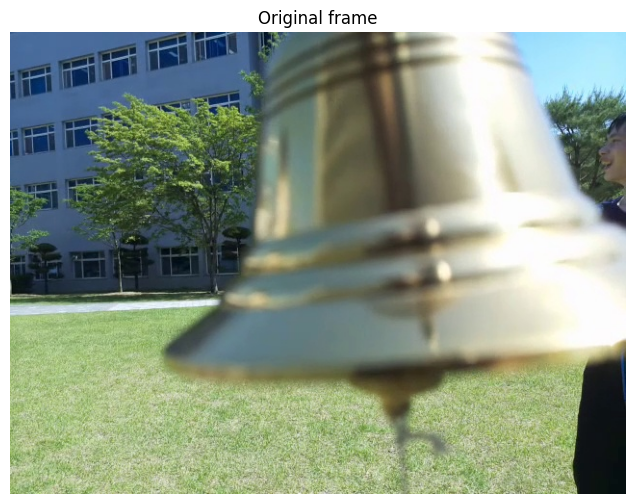

(480, 640, 3)


In [75]:
frame = cv2.imread(IMG_PATH)

if frame is None:
    raise FileNotFoundError(f"Could not read image: {IMG_PATH}")

show(frame, "Original frame")
print(frame.shape)

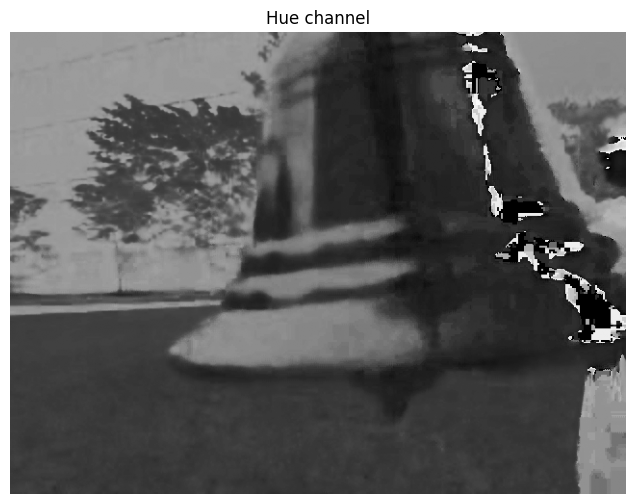

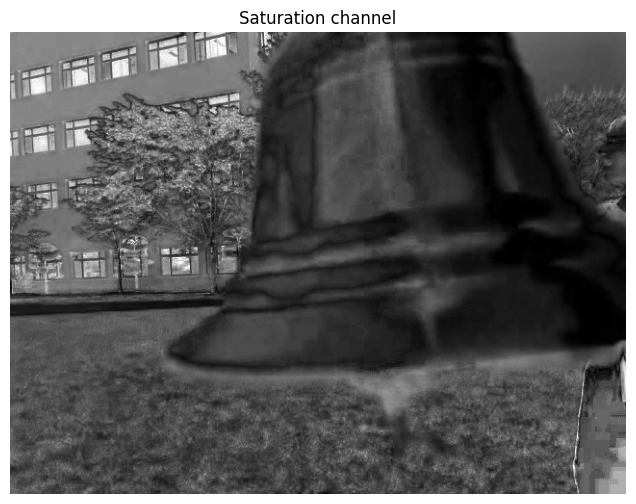

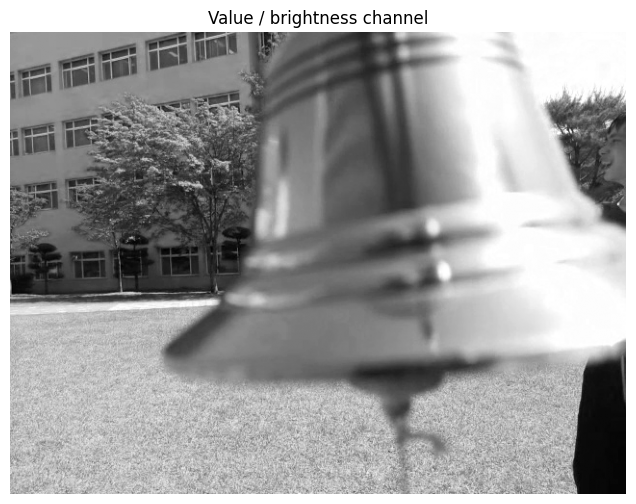

H range: 0 177
S range: 0 255
V range: 11 255


In [76]:
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

h, s, v = cv2.split(hsv)

show(h, "Hue channel")
show(s, "Saturation channel")
show(v, "Value / brightness channel")

print("H range:", h.min(), h.max())
print("S range:", s.min(), s.max())
print("V range:", v.min(), v.max())


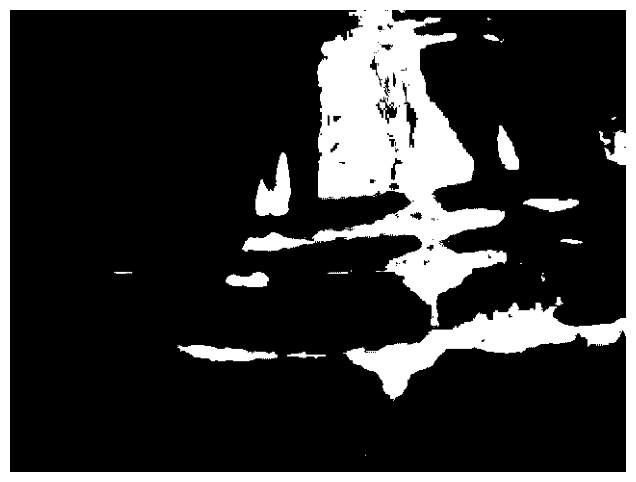

In [77]:
# 2. Define strict HSV boundaries for metallic gold/brass
# Lower bound: captures dark gold / bronze shadows [Hue, Saturation, Value]
lower_gold = np.array([15, 30, 30])
# Upper bound: captures bright yellow-gold reflections
upper_gold = np.array([30, 255, 255])

# Create the initial binary mask
mask = cv2.inRange(hsv, lower_gold, upper_gold)

# Clean up reflections and shadows inside the metallic bell
# Closing (Dilate then Erode) fills in internal glare holes
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (50, 50))
cleaned_mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
# Opening (Erode then Dilate) removes tiny random background noise
cleaned_mask = cv2.morphologyEx(cleaned_mask, cv2.MORPH_OPEN, kernel)
show(mask)

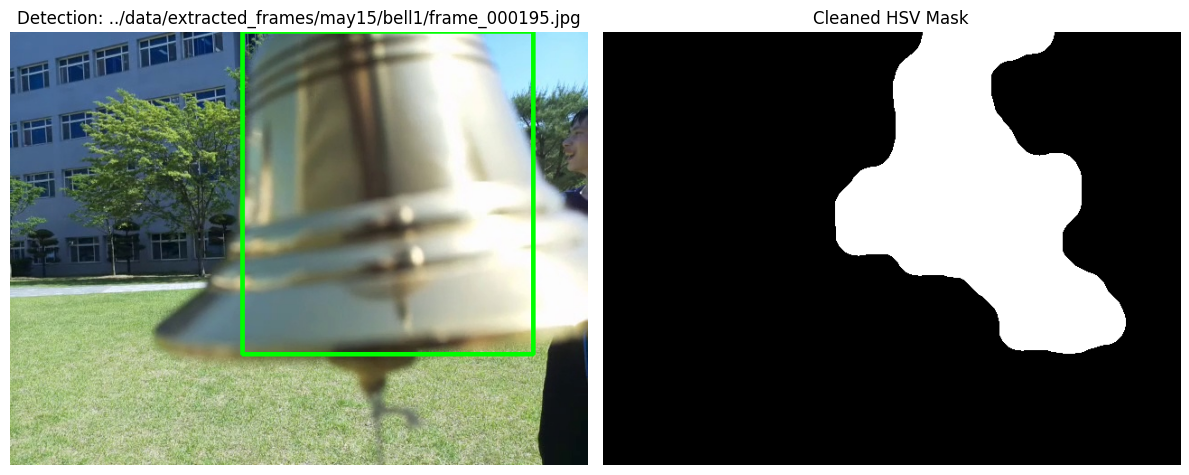

--------------------------------------------------------------------------------


In [78]:


# # 1. Define paths to your test images
# image_paths = ["bell_test1.jpg", "bell_test2.jpg", "bell_test3.jpg"]



# for path in image_paths:
    # Load the image
    # img = cv2.imread(path)
    # if img is None:
    #     print(f"Could not load image: {path}\n" + "-"*50)
    #     continue
        
    # # Resize for consistent processing in close-up environments
    # img = cv2.resize(img, (640, 480))
output = frame.copy()

# # Convert to HSV color space
# hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Find contours of the detected shapes
contours, _ = cv2.findContours(cleaned_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

bell_detected = False

if contours:
    # Sort contours to find the largest one (likely the close-up bell)
    largest_contour = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest_contour)
    
    # Filter out tiny noise artifacts (adjust 2000 based on camera closeness)
    if area > 2000: 
        bell_detected = True
        
        # Get bounding box coordinates
        x, y, w, h = cv2.boundingRect(largest_contour)
        
        # Draw a green bounding box around the bell
        cv2.rectangle(output, (x, y), (x + w, y + h), (0, 255, 0), 4)
        
        # Label it
        cv2.putText(output, f"Bell: {int(area)}px", (x, y - 10), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
if not bell_detected:
    cv2.putText(output, "No Bell Found", (30, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 255), 3)
                
# OpenCV uses BGR, but Matplotlib needs RGB to display colors correctly
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

# Set up the Matplotlib grid for side-by-side rendering
plt.figure(figsize=(12, 6))

# Left subplot: Detection result
plt.subplot(1, 2, 1)
plt.imshow(output_rgb)
plt.title(f"Detection: {IMG_PATH}")
plt.axis("off")

# Right subplot: The isolated mask logic
plt.subplot(1, 2, 2)
plt.imshow(cleaned_mask, cmap="gray")
plt.title("Cleaned HSV Mask")
plt.axis("off")

plt.tight_layout()
plt.show()
print("-" * 80)
